In [2]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import random
from PIL import Image
import seaborn as sns
import numpy as np
from tqdm import tqdm
from joblib import Parallel, delayed

# Datasets
#### Datasets for the project

| Dataset | Description | Link |
|---------|-------------|------|
| CheXpert / MIMIC-CXR | Large chest X-ray datasets with radiologist labels | https://physionet.org/content/mimic-cxr/2.1.0/ https://physionet.org/content/mimic-cxr-jpg/2.1.0/ https://github.com/MIT-LCP/mimic-cxr |
| ISIC Skin Lesion Dataset | Dermoscopic images with histopathology-confirmed labels| https://challenge.isic-archive.com/data/#2024 |
| NIH Chest X-ray Dataset | Over 100,000 frontal-view X-rays| https://nihcc.app.box.com/v/ChestXray-NIHCC https://www.kaggle.com/datasets/nih-chest-xrays/data |
| PadChest | Multilabel chest X-ray dataset with over 160,000 images| https://bimcv.cipf.es/bimcv-projects/padchest/ |

### Download the Dataset form Kaggle (NIH Chest X-ray Dataset)

In [ ]:
# NOTE: Nih-chest-xrays dataset is 42 GB of data (make sure your disk has enough space for it)
# The following cell block will download the dataset and skip if the dataset is already downloaded

In [ ]:
from dotenv import load_dotenv
from kaggle.api.kaggle_api_extended import KaggleApi

# Load credentials
load_dotenv()
os.environ["KAGGLE_USERNAME"] = os.getenv("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = os.getenv("KAGGLE_KEY")

# Authenticate
api = KaggleApi()
api.authenticate()


### DO this for the Public dataset (uplaoded by users)

# Example dataset download

if not Path('./data').exists():

    api.dataset_download_files(
        "nih-chest-xrays/data",  # dataset path from Kaggle URL
        path="./data",
        unzip=True,
        quiet=False # progress bar for download
    )

    print("Download complete")

else:
    print('Dataset directory already exists')

Dataset directory already exists


## Dataset Inspection

In [89]:
# Check for all the files in the dataset folder

DATA_DIR = Path('data')
files = os.listdir(DATA_DIR)

files

['ARXIV_V5_CHESTXRAY.pdf',
 'BBox_List_2017.csv',
 'Data_Entry_2017.csv',
 'FAQ_CHESTXRAY.pdf',
 'images_001',
 'images_002',
 'images_003',
 'images_004',
 'images_005',
 'images_006',
 'images_007',
 'images_008',
 'images_009',
 'images_010',
 'images_011',
 'images_012',
 'LOG_CHESTXRAY.pdf',
 'README_CHESTXRAY.pdf',
 'test_list.txt',
 'train_val_list.txt']

* The 'Data_Entry_2017.csv' files contains all the information image index, label data, and other data like (...........)

* the `images_001` to `images_012` contains all 112,120 X-ray images
* the `test_list.txt` contains the images file index of the test split
* the `train_val_list.txt` contains the images file index of the train val split 

In [22]:
cols = [
    'Image Index',
    'Finding Labels',
    'Follow-up #',
    'Patient ID',
    'Patient Age',
    'Patient Gender',
    'View Position',
    'OriginalImage[Width',
    'Height]',
    'OriginalImagePixelSpacing[x',
    'y]'
]

# Load the Metadata/Annotation CSV file
df = pd.read_csv('data/Data_Entry_2017.csv', usecols=cols)

# print few rows of the dataframe
# df[:10]
df.sample(n=10, random_state=42)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
89645,00022260_003.png,No Finding,3,22260,54,F,PA,2542,2434,0.143000,0.143000
47446,00012048_007.png,Infiltration|Mass|Nodule,7,12048,65,M,AP,2500,2048,0.168000,0.168000
57963,00014352_005.png,No Finding,5,14352,6,M,PA,2992,2033,0.143000,0.143000
22863,00006040_001.png,No Finding,1,6040,18,F,AP,2500,2048,0.171000,0.171000
43431,00011202_002.png,No Finding,2,11202,19,M,AP,2500,2048,0.168000,0.168000
8601,00002275_007.png,Emphysema|Infiltration|Pneumothorax,7,2275,62,M,PA,2500,2048,0.171000,0.171000
13260,00003446_008.png,No Finding,8,3446,49,M,AP,2500,2048,0.171000,0.171000
111184,00030350_000.png,Atelectasis,0,30350,24,M,PA,2021,2020,0.194311,0.194311
17284,00004640_000.png,No Finding,0,4640,37,F,PA,2048,2500,0.171000,0.171000
33809,00008858_007.png,Effusion,7,8858,49,F,AP,2500,2048,0.168000,0.168000


In [43]:
print(f'Total Number of rows in the Metadata dataframe: {len(df)} rows') # -> 112120 -> equalling the number of X-ray images in the dataset 
print(f'\nColumns in the Metadata dataframe:\n  {list(df.columns)}')

Total Number of rows in the Metadata dataframe: 112120 rows

Columns in the Metadata dataframe:
  ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]']


## Handle Missing Data Values

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  str    
 1   Finding Labels               112120 non-null  str    
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  str    
 6   View Position                112120 non-null  str    
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
dtypes: float64(2), int64(5), str(4)
memory usage: 9.4 MB


In [71]:
# Handle missing data values | Shows number of missing values per columns
df.isna().sum() # -> if all `0` means no missing data values

Image Index                    0
Finding Labels                 0
Follow-up #                    0
Patient ID                     0
Patient Age                    0
Patient Gender                 0
View Position                  0
OriginalImage[Width            0
Height]                        0
OriginalImagePixelSpacing[x    0
y]                             0
dtype: int64

# Explore the Labels of the data

In [48]:
labels_list = list(df['Finding Labels'].unique())

print(len(labels_list))
# labels_list
labels_list[:10]

836


['Cardiomegaly',
 'Cardiomegaly|Emphysema',
 'Cardiomegaly|Effusion',
 'No Finding',
 'Hernia',
 'Hernia|Infiltration',
 'Mass|Nodule',
 'Infiltration',
 'Effusion|Infiltration',
 'Nodule']

### NOTE: A single data has multiple labels. So its multi-label problem

In [49]:
# Lets check the unique labels in the dataset

labels_list_seperated = [word for label in labels_list for word in label.split('|')]

unique_labels = list(set(labels_list_seperated))

print(len(unique_labels))
unique_labels.sort()
print(unique_labels)

15
['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


##### Contains 14 classes: `['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'] `

##### And also `'No Finding'` class

==========================================

### Since this is a multilabel classification problem.
#### SO we perform 
## Multi-Hot Label Encoding

* The NIH dataset stores labels as pipe-separated strings like `"Atelectasis|Effusion"`.
* Convert these into binary vectors of length 14 (one entry per disease class).
* `No Finding` is treated as all-zeros: the model doesn't need a 15th output for it.

In [50]:
CLASSES = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
    ]

NUM_CLASSES = len(CLASSES)
print(f'Number of classes: {NUM_CLASSES}')
print(f'Classes: {CLASSES}')

Number of classes: 14
Classes: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [51]:
def encode_labels(label_string: str, classes:list) -> np.ndarray:
    """
    Convert a pipe-separated label string to a multi-hot binary vector

    Args:
        label string: e.g. 'Atelectasis|Effusion' or 'No Finding'
        classes: ordered list of 14 disease class names

    Returns:
        np.ndarray of shape (14,) with 0s and 1s
    """
    vec = np.zeros(len(classes), dtype=np.float32)
    if label_string == 'No Finding':
        return vec # all zeros
    for label in label_string.split('|'):
        label = label.strip() # removes whitespace form the beginning and end of the string
        if label in classes:
            vec[classes.index(label)] = 1.0
    return vec

In [54]:
label_string_sample = df.iloc[1]['Finding Labels']
label_string_sample

'Cardiomegaly|Emphysema'

In [55]:
label_matrix = np.stack(
    df['Finding Labels'].apply(lambda x: encode_labels(x, CLASSES)).values
)

label_matrix.shape

(112120, 14)

In [56]:
print(f'Label matrix shape: {label_matrix.shape}') # (112120, 14)

print(f'\nPer-class positive counts:')

for i, cls in enumerate(CLASSES):
    count = label_matrix[:, i].sum()
    print(f'  {cls:25s}: {int(count):6d} ({count/len(df)*100:.2f}%)')

Label matrix shape: (112120, 14)

Per-class positive counts:
  Atelectasis              :  11559 (10.31%)
  Cardiomegaly             :   2776 (2.48%)
  Consolidation            :   4667 (4.16%)
  Edema                    :   2303 (2.05%)
  Effusion                 :  13317 (11.88%)
  Emphysema                :   2516 (2.24%)
  Fibrosis                 :   1686 (1.50%)
  Hernia                   :    227 (0.20%)
  Infiltration             :  19894 (17.74%)
  Mass                     :   5782 (5.16%)
  Nodule                   :   6331 (5.65%)
  Pleural_Thickening       :   3385 (3.02%)
  Pneumonia                :   1431 (1.28%)
  Pneumothorax             :   5302 (4.73%)


## Class Distribution (multi-label distribution graph)

In [72]:
all_labels = df['Finding Labels']

In [73]:
labels_list_seperated = [word for label in all_labels for word in label.split('|')]

total = len(labels_list_seperated)

from collections import Counter

labels_count = Counter(labels_list_seperated)

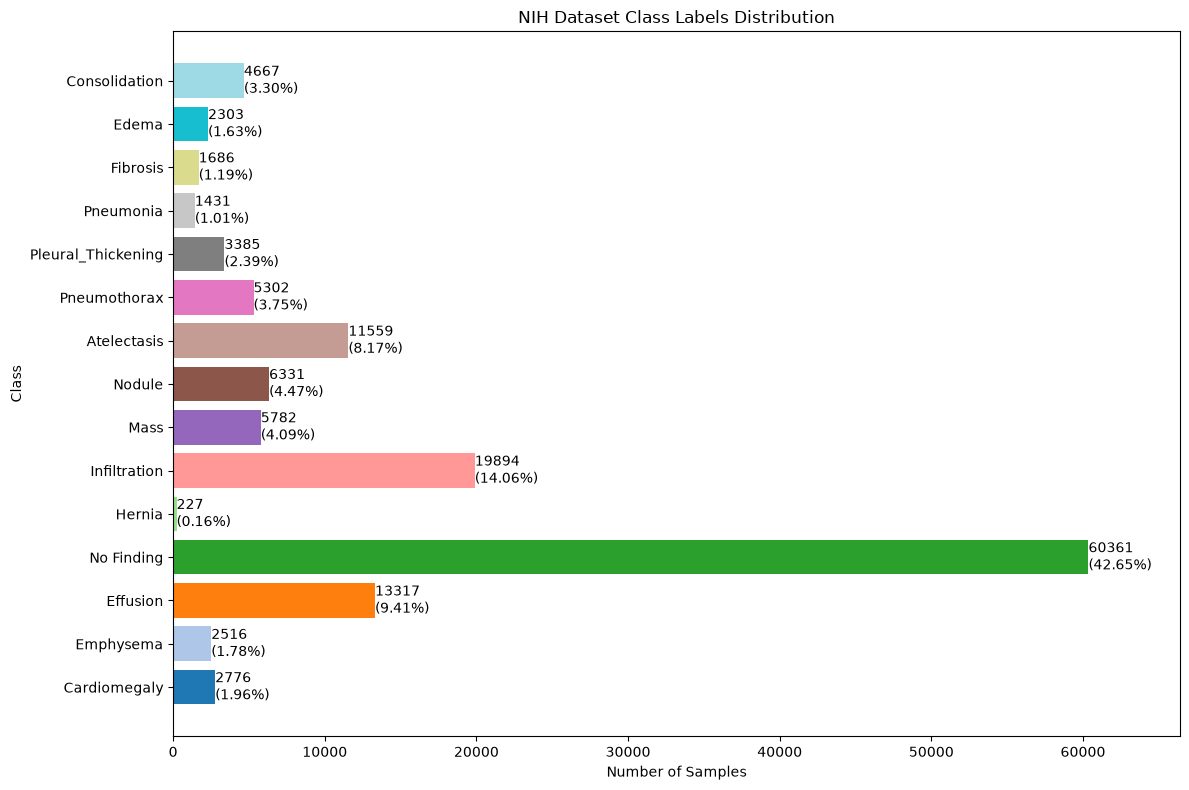

In [75]:
# Infection Distribution

plt.figure(figsize=(12, 8))
bars = plt.barh(labels_count.keys(), labels_count.values(), color=plt.cm.tab20(np.linspace(0, 1, 15)))
plt.bar_label(bars, labels=[f"{value}\n({value/total*100:.2f}%)" for value in labels_count.values()])
plt.xlim(0, 1.1*max(labels_count.values()))
plt.ylabel('Class')
plt.xlabel('Number of Samples')
plt.title('NIH Dataset Class Labels Distribution')

plt.tight_layout()

plt.show()

In [ ]:
# The Dataset Class imbalance is very high. We will address this later with certain class removal and Image augmentation and more

## Load the images path of all the images data

In [60]:
# Image Path of all the data images 

images_list = list(path.glob('./**/images/*.png'))
print(len(images_list)) # -> should match the number of rows in the dataframe i.e: 112120
images_list[:5]

112120


[WindowsPath('data/images_001/images/00000001_000.png'),
 WindowsPath('data/images_001/images/00000001_001.png'),
 WindowsPath('data/images_001/images/00000001_002.png'),
 WindowsPath('data/images_001/images/00000002_000.png'),
 WindowsPath('data/images_001/images/00000003_000.png')]

In [61]:
# Use the parallel processing via `joblib` library to read the image dimensions faster

def image_dim(path):
    with Image.open(path) as img:
        return {
            'file': path,
            'width': img.width,
            'height': img.height,
        }
    
dim_file_path = Path('./Dimensions_Data.csv')

if not dim_file_path.exists():

    parallel_obj = Parallel(n_jobs = -1)
    dim_data = parallel_obj(delayed(image_dim)(img_path) for img_path in images_list)

    # Convert the dimensions data of the images into a dataframe and save as csv file
    df_dim = pd.DataFrame(dim_data)
    df_dim.to_csv(dim_file_path, index=False)

In [63]:
# Read all the unique values for dimensions of the images
df_dim = pd.read_csv(dim_file_path)

df_dim['width'].unique(), df_dim['width'].unique() # -> if only one value per width and height, it means all images are in dimensions of those values

(array([1024]), array([1024]))

## Print some sample images for visualization

In [64]:
# Prints some of the data images with labels

def print_image(rows, cols, dataframe, seed=42):

    total_subplots = rows * cols

    random.seed(seed)
    sample_path = random.sample(images_list, total_subplots)

    fig, axes = plt.subplots(rows, cols, figsize=(9, 9))
    axes = axes.flatten()

    for index, value in enumerate(sample_path):
        # plot the image
        img = Image.open(value)
        axes[index].imshow(img, cmap='grey')

        # Label for the plotted image
        image_index = f'{value.stem}.png'
        label = dataframe[dataframe['Image Index'] == image_index]['Finding Labels']
        
        # Green if not infected | Red if infected
        color = 'green' if label.iloc[0] == 'No Finding' else 'red'

        axes[index].set_title(label.iloc[0], color=color)

        axes[index].axis('off')

    plt.tight_layout()

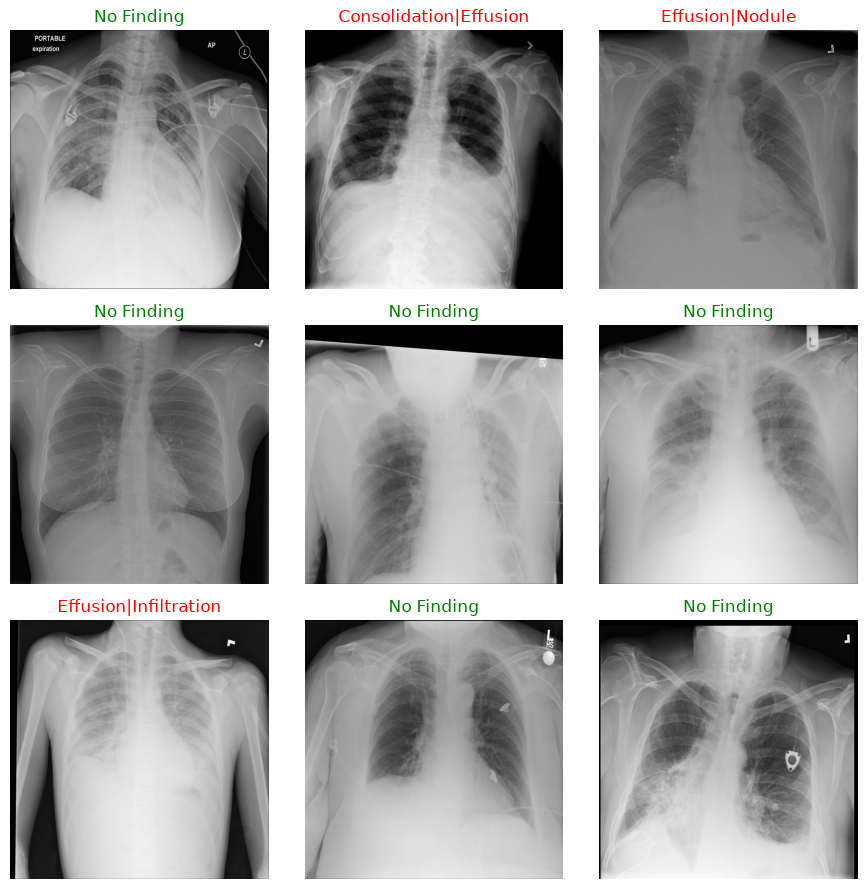

In [67]:
print_image(3, 3, df, seed=42)

### Gender Distribution

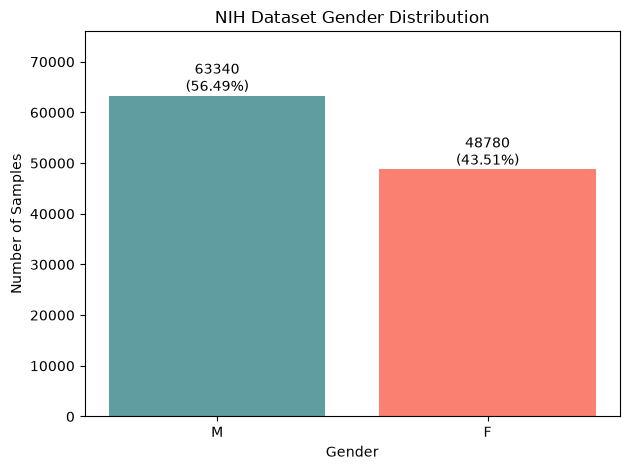

In [22]:
# Question: Do u wanna do gender distribution only or do gender distribution in consideration to target


count = df['Patient Gender'].value_counts()


# # convet this droup by series to dataframe with proper values and index
# data_fr = pd.DataFrame(data={'count': count.values}, index=count.index).reset_index()


data_class = {
    count.keys()[0]: count.iloc[0],
    count.keys()[1]: count.iloc[1],
}

data_class



total = sum(data_class.values())
# Gender Distribution

# plt.figure(figsize=(12, 8))
bars = plt.bar(data_class.keys(), data_class.values(), color=['cadetblue', 'salmon'])
plt.bar_label(bars, labels=[f"{value}\n({value/total*100:.2f}%)" for value in data_class.values()])
plt.ylim(0, 1.2*max(data_class.values()))
plt.xlabel('Gender')
plt.ylabel('Number of Samples')
plt.title('NIH Dataset Gender Distribution')

plt.tight_layout()

plt.show()


### View Position(PA vs AP) Distribution

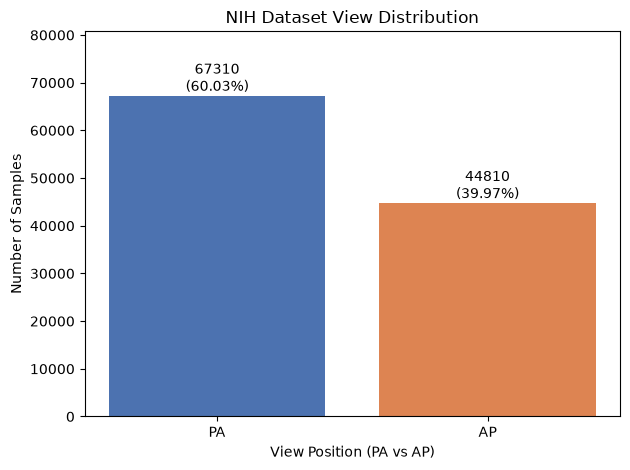

In [85]:
count = df['View Position'].value_counts()

# # convet this droup by series to dataframe with proper values and index
# data_fr = pd.DataFrame(data={'count': count.values}, index=count.index).reset_index()

data_class = {
    count.keys()[0]: count.iloc[0],
    count.keys()[1]: count.iloc[1],
}

data_class



total = sum(data_class.values())

# View Position Distribution

# plt.figure(figsize=(12, 8))
bars = plt.bar(data_class.keys(), data_class.values(), color=["#4C72B0", "#DD8452"])
plt.bar_label(bars, labels=[f"{value}\n({value/total*100:.2f}%)" for value in data_class.values()])
plt.ylim(0, 1.2*max(data_class.values()))
plt.xlabel('View Position (PA vs AP)')
plt.ylabel('Number of Samples')
plt.title('NIH Dataset View Distribution')

plt.tight_layout()

plt.show()

### Age Distribution and Histogram

In [23]:
### Unique values in the age metadata

age_data = df['Patient Age']
unique_age = age_data.unique()
unique_age.sort()
unique_age

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95, 148, 149, 150, 151, 152, 153, 154, 155, 411,
       412, 413, 414])

In [24]:
# There are age like 150, 155, 411.. which are outliers in the data

age_data.describe()

count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64

In [25]:
Q1 = age_data.quantile(0.25)
Q2 = age_data.quantile(0.5)
Q3 = age_data.quantile(0.75)

IQR = Q3 - Q1

print(Q1, Q2, Q3, IQR)

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(lower_limit, upper_limit)

35.0 49.0 59.0 24.0
-1.0 95.0


In [26]:
# all the columns with the outlier age data
df[(df['Patient Age'] > upper_limit)|(df['Patient Age'] < lower_limit)]

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
20852,00005567_000.png,Effusion|Pneumonia,0,5567,412,M,AP,3056,2544,0.139,0.139
46965,00011973_002.png,Edema,2,11973,414,M,AP,3056,2544,0.139,0.139
48284,00012238_010.png,No Finding,10,12238,148,M,PA,2992,2991,0.143,0.143
55742,00013950_000.png,No Finding,0,13950,148,M,PA,2964,2939,0.143,0.143
58650,00014520_026.png,Infiltration|Mass,26,14520,150,M,PA,2992,2991,0.143,0.143
62929,00015558_000.png,No Finding,0,15558,149,M,PA,2992,2991,0.143,0.143
74884,00018366_044.png,Pneumothorax,44,18366,152,F,PA,2302,2991,0.143,0.143
78795,00019346_000.png,Infiltration,0,19346,151,F,PA,2678,2774,0.143,0.143
84810,00020900_002.png,No Finding,2,20900,411,M,AP,3056,2544,0.139,0.139
85404,00021047_002.png,Mass|Pleural_Thickening,2,21047,412,M,AP,3056,2544,0.139,0.139


In [27]:
# new df with all the age outliers removed

no_age_outlier_df = df[(df['Patient Age'] > lower_limit)&(df['Patient Age'] < upper_limit)]
unique_values = no_age_outlier_df['Patient Age'].unique()
unique_values.sort()
unique_values

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94])

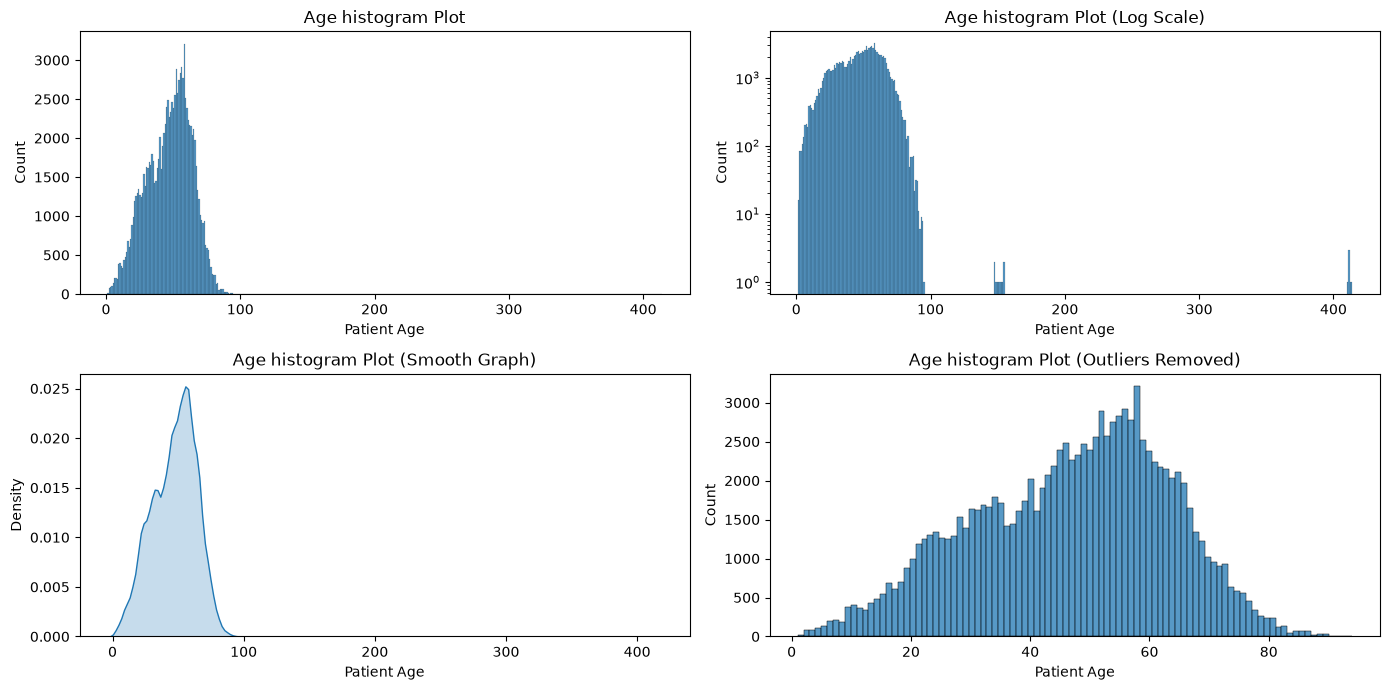

In [28]:
# Plot histograms for the age data

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()

sns.histplot(age_data, ax=axes[0])
axes[0].set_title('Age histogram Plot')

# frequncy data of the age is in log scale to visualize the less occuring age data
sns.histplot(age_data, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Age histogram Plot (Log Scale)')


sns.kdeplot(age_data, fill=True, ax=axes[2])
axes[2].set_title('Age histogram Plot (Smooth Graph)')

sns.histplot(no_age_outlier_df['Patient Age'], ax=axes[3])
axes[3].set_title('Age histogram Plot (Outliers Removed)')

plt.tight_layout()

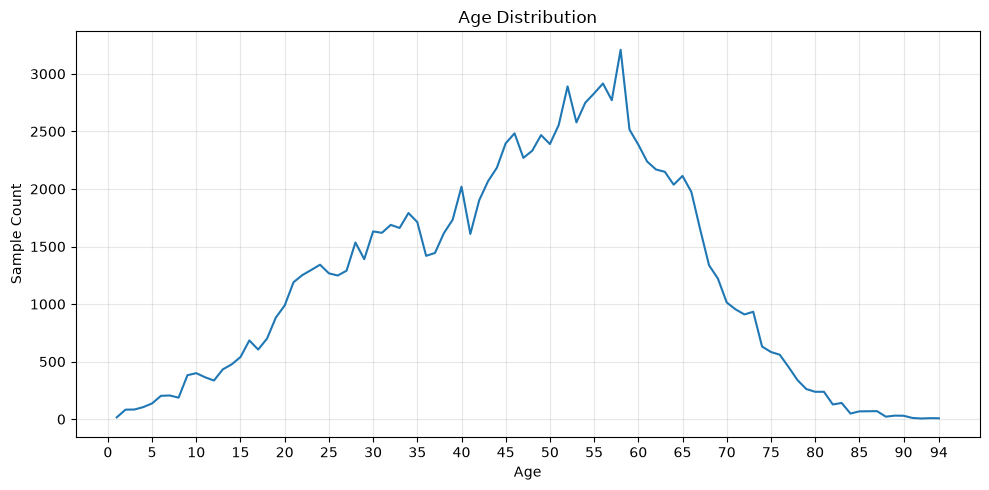

In [29]:
# Dataset Class distribution by Age

temp = no_age_outlier_df['Patient Age'].value_counts().sort_index()

age_distribution = pd.DataFrame(data={'count': temp.values}, index=temp.index).reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=age_distribution, x='Patient Age', y='count')

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Sample Count')

ticks = list(range(0, max(temp.index), 5))
ticks.append(max(temp.index))
plt.xticks(ticks)
plt.grid(alpha=0.3)

plt.tight_layout()

# EDA (Exploratory Data Analysis)

# MODEL

In [31]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

In [32]:
# Verify GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.3f} GB')
    print(f'VRAM allocated: {torch.cuda.memory_allocated(0) / 1e9:.4f} GB')

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM total: 4.294 GB
VRAM allocated: 0.0000 GB


## Split the Data into Train / Val / Test Set


NIH provides official split files. **Should always use these** - no random split.
Random splits leak patient data across train/test because the same patient can have multiple X-rays. The official split is patient-level.

We carve 10% of the official `train_val_list` set for validation (still patient-aware since the NIH file already handles patient-level separation).

* `Train set`: Used to learn model parameters.
* `Validation set`: Used for tuning and model selection.
* `Test set`: Used for final evaluation on unseen data.

In [ ]:
# Load the official split files

with open(DATA_DIR / 'train_val_list.txt') as f:
    train_val_files = set(line.strip() for line in f)

with open(DATA_DIR / 'test_list.txt') as f:
    test_files = set(line.strip() for line in f)

print(f'Official train + val files: {len(train_val_files):,}')
print(f'Official test files:        {len(test_files):,}')
print(f'Total:                      {len(train_val_files)+len(test_files):,}')

Official train + val files: 86,524
Official test files:        25,596
Total:                      112,120


In [ ]:
# Fine-tune a pre-trained model (ResNet, DenseNet, EfficientNet) on your chosen dataset